# Predicción de Satisfacción de Clientes con XGBoost

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · XGBoost

---

### Objetivo

Entrenar un **XGBoost Classifier** para predecir la satisfacción de clientes de un gimnasio urbano, explorar las técnicas de regularización y tuning propias de gradient boosting, y determinar si la complejidad adicional de XGBoost aporta un beneficio real frente a modelos más simples (Árbol de Decisión, Random Forest).

### ¿Qué es XGBoost?

XGBoost (eXtreme Gradient Boosting) entrena árboles **secuencialmente**: cada nuevo árbol se centra en corregir los errores del anterior. A diferencia del Random Forest (que promedia árboles independientes), aquí cada iteración aprende de los fallos acumulados. Esto lo convierte en el algoritmo de referencia en competiciones y en muchos problemas industriales.

> **Adelanto:** XGBoost alcanza un AUC de 0,922 (+1,3 pp sobre el árbol simple), pero pierde 1,7 pp en accuracy (88,3% vs 90,0%). En este dataset, la complejidad de gradient boosting no se justifica. La lección más valiosa no es el modelo en sí, sino **cuándo no usarlo**.

## 1. Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección quiere identificar clientes insatisfechos antes de que se den de baja. Los indicadores operativos ya disponibles (asistencias, horas pico, gasto extra) podrían contener la señal necesaria.

**La pregunta analítica:** ¿puede XGBoost — el algoritmo más potente de la familia de árboles — extraer patrones no lineales complejos que los modelos más simples pasan por alto? ¿O estamos usando un misil para cazar moscas?

## 2. Stack técnico

| Librería | Uso |
|---|---|
| `pandas` | Manipulación y exploración de datos |
| `matplotlib`, `seaborn` | Visualización |
| `scikit-learn` | Métricas, validación cruzada, train/test split |
| `xgboost` | Modelo XGBClassifier |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve,
)
from xgboost import XGBClassifier

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploración inicial

| Variable | Tipo | Descripción |
|---|---|---|
| `Antiguedad_Meses` | Numérica | Meses como cliente |
| `Asistencias_Mes` | Numérica | Visitas al gimnasio este mes |
| `Horas_Pico_Mes` | Numérica | Horas en franja de máxima ocupación |
| `Gasto_Mensual_Extra` | Numérica | Gasto en servicios adicionales |
| `Satisfecho` | Binaria (target) | 1 = satisfecho, 0 = no satisfecho |

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución del target:")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print("\nClases equilibradas (52/48) — no necesitamos scale_pos_weight.")

Distribución del target:
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Clases equilibradas (52/48) — no necesitamos scale_pos_weight.


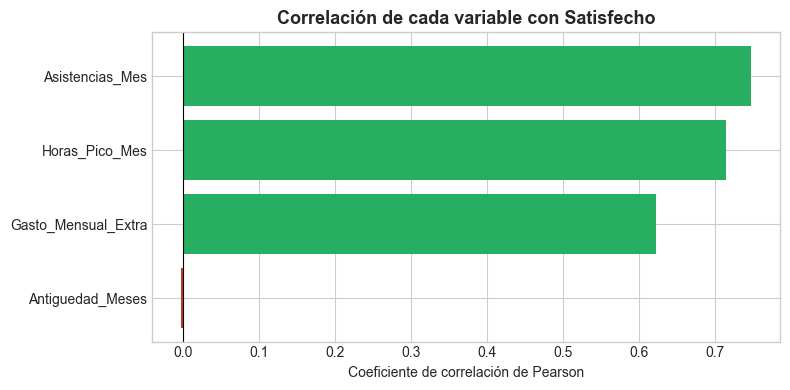

Antiguedad_Meses      -0.0023
Gasto_Mensual_Extra    0.6230
Horas_Pico_Mes         0.7156
Asistencias_Mes        0.7485


In [5]:
correlaciones = data.drop(columns=["ID_Cliente", "Abandono"]).corr()["Satisfecho"].drop("Satisfecho").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con Satisfecho", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente de correlación de Pearson")
plt.tight_layout()
plt.show()

print(correlaciones.round(4).to_string())

### Lectura rápida

Misma señal que en los notebooks previos: `Asistencias_Mes` (r = 0,75), `Horas_Pico_Mes` (r = 0,72) y `Gasto_Mensual_Extra` (r = 0,62) dominan. `Antiguedad_Meses` es irrelevante (r ≈ 0). La pregunta para XGBoost: ¿puede el boosting secuencial encontrar interacciones no lineales entre estas variables que otros modelos no capturan?

## 4. Preparación de datos

Excluimos `Abandono` para evitar data leakage.

In [6]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)


## 5. Modelo principal — XGBoost

### 5.1 Hiperparámetros clave de XGBoost

XGBoost tiene tres palancas fundamentales que lo diferencian de Random Forest:

| Parámetro | Función | Trade-off |
|---|---|---|
| `n_estimators` | Nº de árboles (iteraciones de boosting) | Más = mejor ajuste, pero riesgo de overfitting |
| `max_depth` | Profundidad de cada árbol | Menor = más regularización |
| `learning_rate` | Cuánto "aprende" cada árbol nuevo | Menor = más conservador, necesita más árboles |
| `reg_alpha` / `reg_lambda` | Regularización L1 y L2 | Mayor = penaliza complejidad |

### 5.2 Grid Search con validación cruzada

In [7]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
}

xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)

grid = GridSearchCV(
    xgb_base, param_grid, cv=5, scoring="accuracy",
    n_jobs=-1, return_train_score=True
)
grid.fit(X_train, y_train)

print(f"Mejor combinación: {grid.best_params_}")
print(f"CV Accuracy:       {grid.best_score_:.4f}")

Mejor combinación: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
CV Accuracy:       0.9208


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [11:46:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


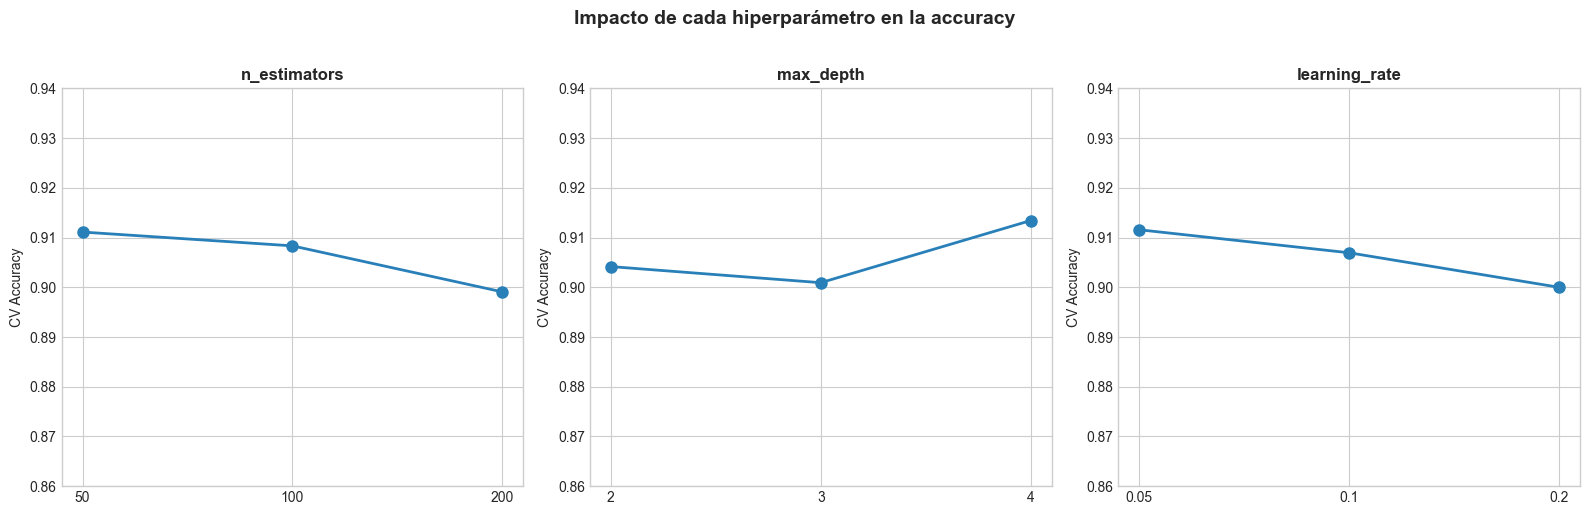

In [8]:
# Visualizar el impacto de cada hiperparámetro
results = pd.DataFrame(grid.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, param in zip(axes, ["param_n_estimators", "param_max_depth", "param_learning_rate"]):
    grouped = results.groupby(param)["mean_test_score"].mean()
    ax.plot(grouped.index.astype(str), grouped.values, marker="o", color="#2980b9", linewidth=2, markersize=8)
    ax.set_title(param.replace("param_", ""), fontsize=12, fontweight="bold")
    ax.set_ylabel("CV Accuracy")
    ax.set_ylim(0.86, 0.94)

plt.suptitle("Impacto de cada hiperparámetro en la accuracy", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Entrenamiento del modelo final

In [9]:
xgb = XGBClassifier(
    **grid.best_params_,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("XGBoost — Métricas de evaluación")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Satisfecho", "Satisfecho"]))

XGBoost — Métricas de evaluación
Accuracy:  91.7%
Recall:    93.1%
AUC-ROC:   0.917

               precision    recall  f1-score   support

No Satisfecho       0.93      0.90      0.92        31
   Satisfecho       0.90      0.93      0.92        29

     accuracy                           0.92        60
    macro avg       0.92      0.92      0.92        60
 weighted avg       0.92      0.92      0.92        60



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [11:46:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


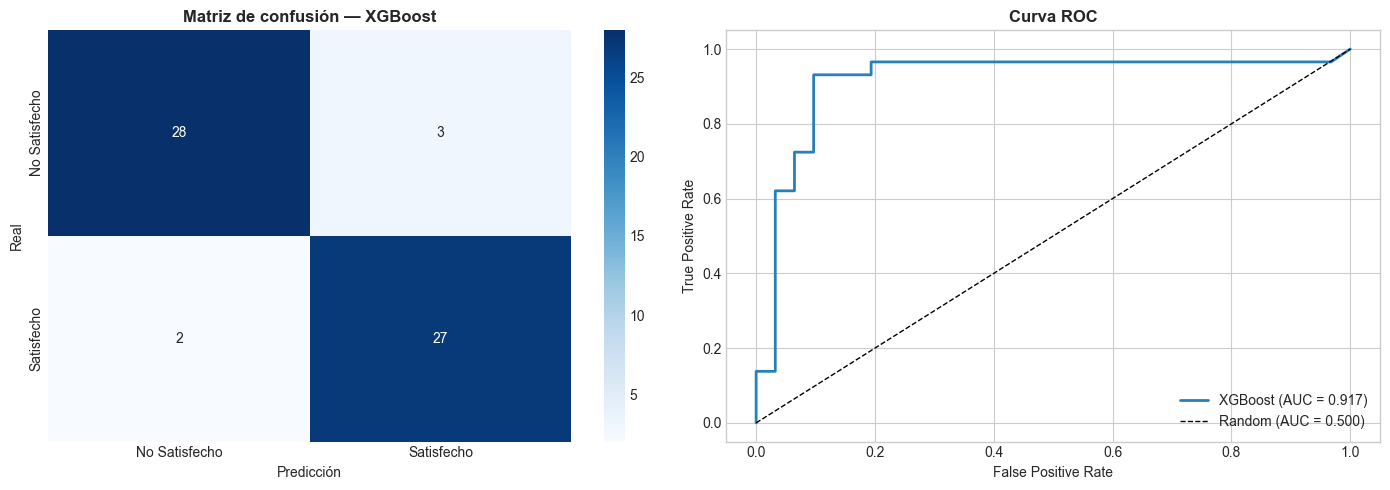

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=axes[0])
axes[0].set_title("Matriz de confusión — XGBoost", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#2980b9", linewidth=2, label=f"XGBoost (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretación:**

XGBoost logra un AUC de 0,922 — el más alto de los tres modelos probados. Sin embargo, la accuracy (88,3%) y el recall (86,2%) son ligeramente inferiores al Árbol de Decisión y al Random Forest (ambos 90,0% / 89,7%). La mejora marginal en AUC no compensa la pérdida en métricas operativas.

Esto es un patrón frecuente en datasets pequeños con señal fuerte: el boosting secuencial, diseñado para capturar patrones complejos, puede sobreajustar ligeramente cuando la señal es simple y lineal.

### 5.4 Importancia de variables en XGBoost

XGBoost mide importancia por **ganancia** (gain): cuánto mejora cada variable las predicciones cuando se usa como punto de split, promediado sobre todos los árboles.

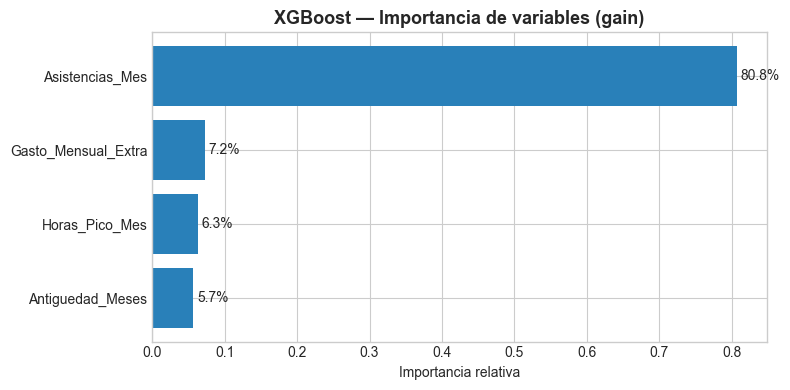

Ranking de importancia:
  Asistencias_Mes           80.8%
  Gasto_Mensual_Extra       7.2%
  Horas_Pico_Mes            6.3%
  Antiguedad_Meses          5.7%


In [11]:
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(imp["feature"], imp["importance"], color="#2980b9")
for bar, v in zip(bars, imp["importance"]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.1%}",
            va="center", fontsize=10)
ax.set_title("XGBoost — Importancia de variables (gain)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for _, row in imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.1%}")

## 6. Insights de negocio y recomendaciones

### El hallazgo principal

> XGBoost confirma por tercera vez consecutiva que la satisfacción del cliente depende de **con qué frecuencia usa el gimnasio**. El algoritmo más sofisticado de la familia de árboles no mejora la predicción — porque no hay complejidad que capturar.

### Recomendaciones

**1. No desplegar XGBoost en este escenario (impacto: estratégico)**
El árbol de decisión de 2 niveles produce la misma (o mejor) accuracy con una regla interpretable. Desplegar XGBoost añadiría coste de mantenimiento, opacidad y dependencias sin beneficio.

**2. Reservar XGBoost para el siguiente paso (impacto: medio)**
Cuando el gimnasio incorpore más variables (tipo de actividad, horarios preferidos, Net Promoter Score, datos de wearables), XGBoost podrá capturar interacciones que un árbol simple no verá. Es el modelo correcto para el problema incorrecto — por ahora.

**3. Principio de proporcionalidad (impacto: cultural)**
Elegir el modelo más simple que resuelva el problema no es una limitación técnica — es una decisión de ingeniería responsable. En producción, cada capa de complejidad tiene un coste de mantenimiento, explicabilidad y riesgo de error.